# NFW Subhalo Stripping: Green/DASH Baseline vs. Du+24 Tidal Heating

Companion to `stripping.ipynb`, using an **NFW** seed instead of Dekel.
Both prescriptions use the same King62 mass-loss kernel; what differs is
the post-stripping profile shape.

**Baseline B (Green / DASH):** `ev.msub` + `Green.update_mass(m)`, reshaping
the profile via the Green+19 DASH transfer function — exponentially truncated
NFW, no tail regeneration. This is what `SubEvo.py` does.

**Custom (Du+24 heating):** `heat_profile` from `subhalo_functions.py` applies
the Du+22 monotonic shell-expansion formalism, injecting
$\varepsilon(r) \propto r^2$ per step. We expect a similar bound remnant shape
if the heating parameters are calibrated correctly.

Both start from the same NFW seed. Baseline A (Dekel/P10) from
`stripping.ipynb` is re-run at the end for a three-way tidal-track comparison.

In [1]:
import numpy as np
import time

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt

%matplotlib inline

import config as cfg
from profiles import NFW, Dekel

%load_ext autoreload
%autoreload 2
import stripping_common as sc


>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...
    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


## Setup

Same host halo and orbital parameters as `stripping.ipynb` for a direct comparison.
The satellite is now an NFW profile (used as the Green seed **and** as the initial
`NumericProfile` for the heating run).

In [2]:
cfg.Mres = 1e1

#---host parameters (identical to stripping.ipynb)
Mv    = 1e9    # host virial mass [Msun]
cNFW  = 11.68  # host NFW concentration

#---NFW satellite parameters
mv0   = 1e6    # satellite virial mass at infall [Msun]
cNFW_sub = 10. # satellite NFW concentration

#---tidal heating parameters
epsh  = 3.
gamma = 2.5

#---time integration
Nstep = 10000
tmax  = 10.  # [Gyr]

#---build host, orbit, NFW satellite
hNFW = NFW(Mv, cNFW)

#---initial orbit (eta=0.5, eccentric, R0=0.7*rh)
R0, z0 = 0.7*hNFW.rh, 0.
xv0, _ = sc.make_orbit(hNFW, R0=R0, z0=z0, eta=0.5)
sat_nfw = NFW(mv0, cNFW_sub)

print(f"Host      : rh = {hNFW.rh:.2f} kpc, rs = {hNFW.rs:.2f} kpc")
print(f"Satellite : rh = {sat_nfw.rh:.2f} kpc, rs = {sat_nfw.rs:.2f} kpc")
print(f"xv0       : R={xv0[0]:.4f} kpc, Vphi={xv0[4]:.4f} kpc/Gyr")

Host      : rh = 20.63 kpc, rs = 1.77 kpc
Satellite : rh = 2.06 kpc, rs = 0.21 kpc
xv0       : R=14.4402 kpc, Vphi=7.9857 kpc/Gyr


## Baseline B: Green/DASH transfer-function evolution

Mirrors `SubEvo.py`: construct a `Green(mv0, cNFW_sub)` profile and evolve it with
`ev.msub` (King62 mass loss). After each step `s.update_mass(m)` reshapes the profile
via the DASH transfer function — exponentially truncated NFW, no Dekel refit.

In [3]:
t0 = time.time()
result_B = sc.evolve_satgen_green(
    hNFW, mv0, cNFW_sub, xv0,
    tmax=tmax, Nstep=Nstep, alpha='conc'
)
print(f"Baseline B (Green/DASH): {time.time()-t0:.1f} s")
print(f"  rmax0={result_B.rmax0:.3f} kpc, vmax0={result_B.vmax0:.3f} kpc/Gyr")
print(f"  final m = {result_B.m[result_B.m>0][-1]:.2e} Msun")

Baseline B (Green/DASH): 9.3 s
  rmax0=0.447 kpc, vmax0=1.779 kpc/Gyr
  final m = 4.15e+04 Msun


## Custom: Du+24 tidal heating with NFW seed

Wrap the same NFW satellite into a `NumericProfile` and evolve with
`heat_profile` (Du+24 monotonic shell expansion) + King62 tidal stripping.

In [4]:
rvals = np.logspace(np.log10(cfg.Rres), np.log10(sat_nfw.rh), 100)
numProfile0 = NumericProfile(rvals, sat_nfw.M(rvals))

t0 = time.time()
result_heat = sc.evolve_heating(
    hNFW, numProfile0, xv0,
    tmax=tmax, Nstep=Nstep, epsh=epsh, gamma=gamma
)
print(f"Du+24 heating (NFW seed): {time.time()-t0:.1f} s")
print(f"  rmax0={result_heat.rmax0:.3f} kpc, vmax0={result_heat.vmax0:.3f} kpc/Gyr")
print(f"  final m = {result_heat.m[result_heat.m>0][-1]:.2e} Msun")

Du+24 heating (NFW seed): 26.4 s
  rmax0=0.446 kpc, vmax0=1.780 kpc/Gyr
  final m = 1.48e+05 Msun


## Comparison: tidal tracks and mass loss

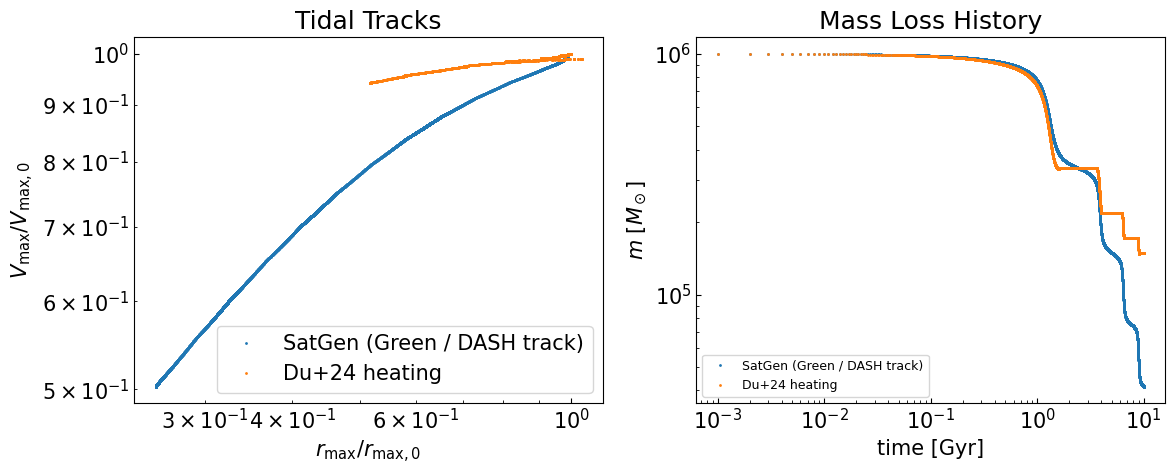

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([result_B, result_heat], ax=axes[0])
sc.plot_mass_loss([result_B, result_heat], ax=axes[1])
plt.tight_layout()
plt.show()

## Profile evolution snapshots

Density, enclosed mass, and circular velocity at evenly-spaced time snapshots.
Colour runs from dark (early) to light (late).

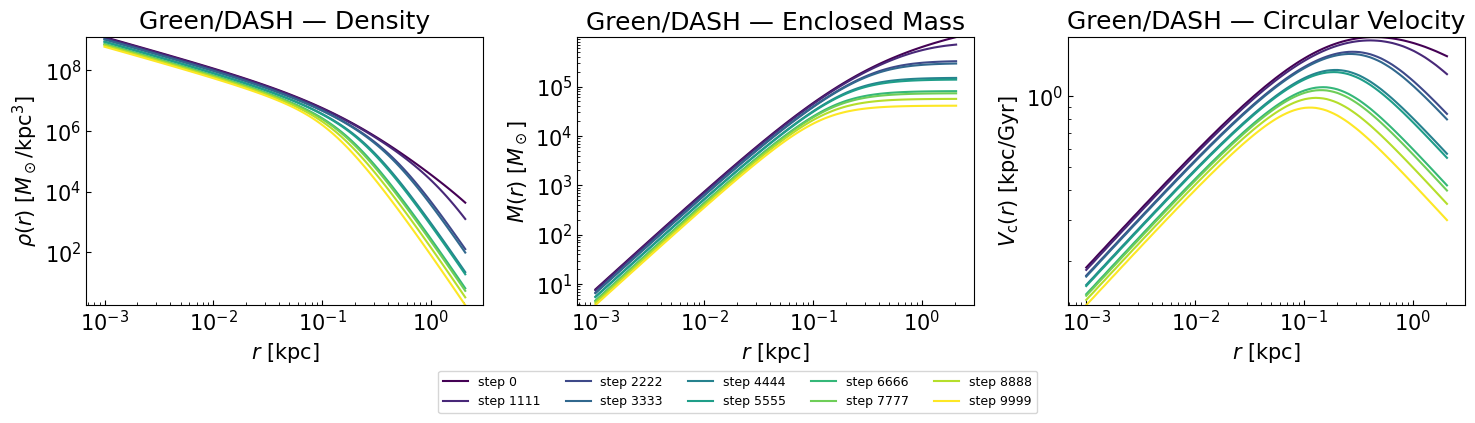

In [7]:
shared_ylims = sc.profile_ylims(result_B, result_heat)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(result_B, axes=axes, title_prefix='Green/DASH — ', ylims=shared_ylims)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

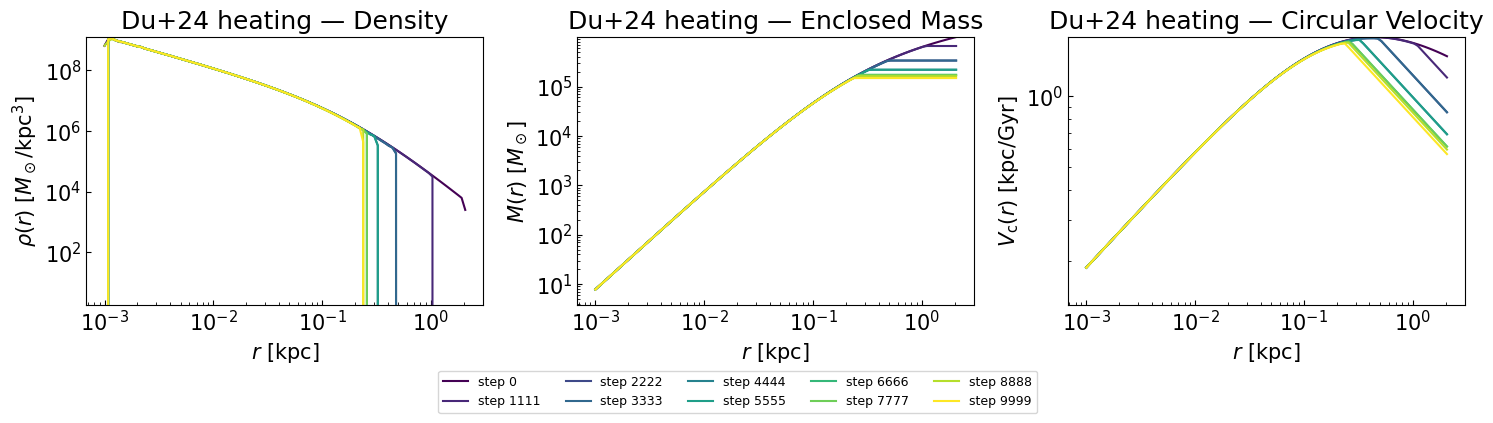

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sc.plot_profile_snapshots(result_heat, axes=axes, title_prefix='Du+24 heating — ', ylims=shared_ylims)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=5)
plt.tight_layout()
plt.show()

## Orbital radius evolution

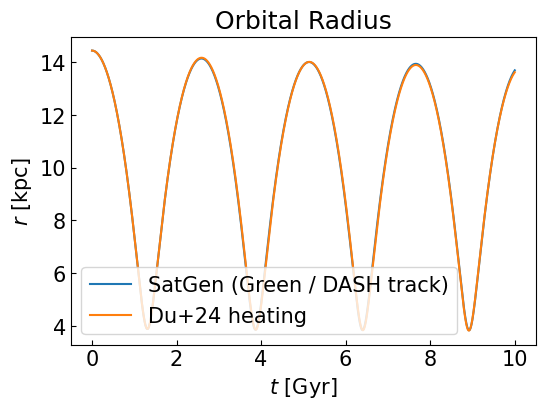

In [9]:
sc.plot_orbit([result_B, result_heat])
plt.show()

## All three baselines on the tidal track

Re-run Baseline A (Dekel/P10 from `stripping.ipynb`) with the same host and orbit
so all three prescriptions can be compared on a single tidal-track plot.

Baseline A (Dekel/P10): 4.6 s


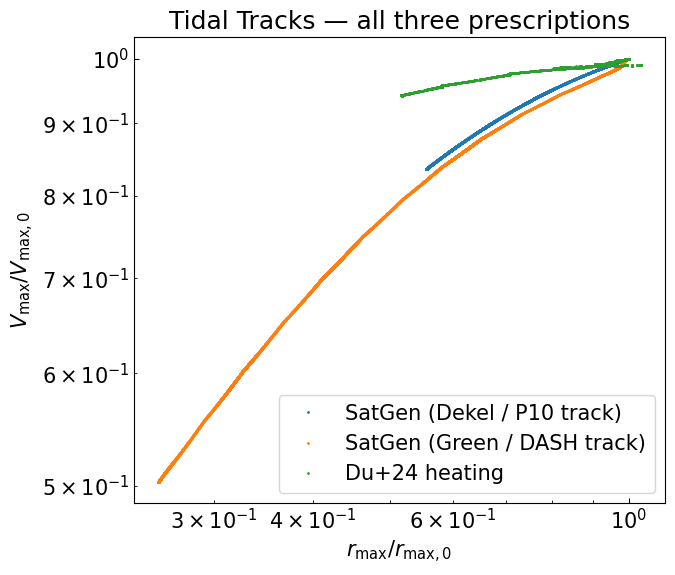

In [10]:
sat_dekel = Dekel(mv0, 100., 1.0 + cfg.eps)

t0 = time.time()
result_A = sc.evolve_satgen_dekel(hNFW, sat_dekel, xv0, tmax=tmax, Nstep=Nstep)
print(f"Baseline A (Dekel/P10): {time.time()-t0:.1f} s")

fig, ax = plt.subplots(figsize=(7, 6))
sc.plot_tidal_track([result_A, result_B, result_heat], ax=ax,
                    title='Tidal Tracks — all three prescriptions')
plt.tight_layout()
plt.show()